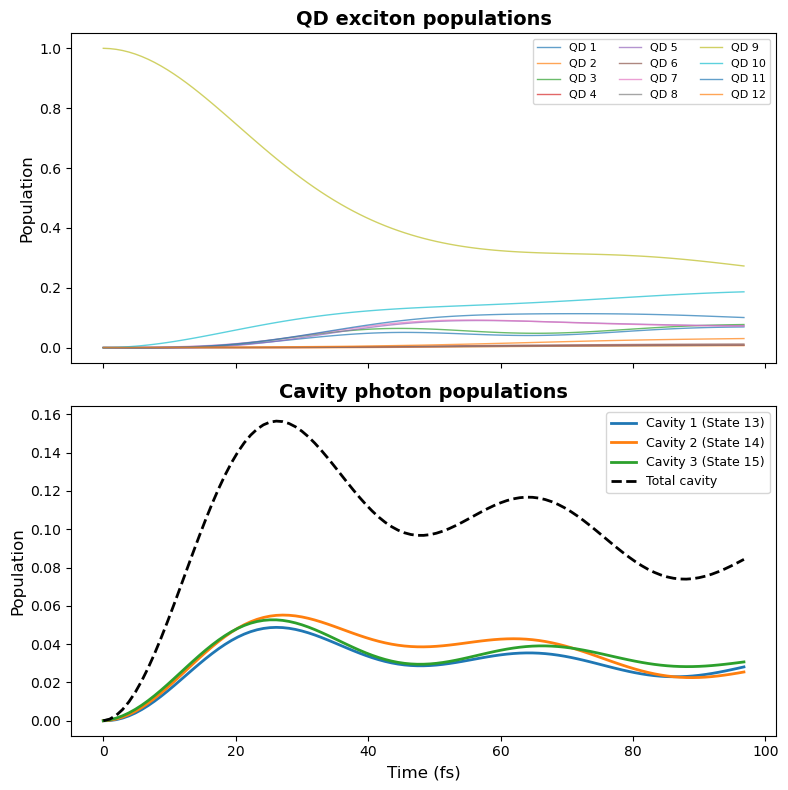

Max cavity populations:
  Cavity 1: 0.048766
  Cavity 2: 0.0551906
  Cavity 3: 0.0526951
  Total cavity: 0.156495


In [1]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 1-12: QD exciton states
- States 13-15: cavity photon states
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 6
nstate_per_qd = 2
n_cavity = 3
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for state in range(n_qd_states):
    axes[0].plot(time, qd_pop[:, state], label=f"QD {state + 1}", linewidth=1, alpha=0.7)
axes[0].set_ylabel("Population", fontsize=12)
axes[0].set_title("QD exciton populations", fontsize=14, fontweight="bold")
axes[0].legend(ncol=3, fontsize=8)

for cav in range(n_cavity):
    axes[1].plot(time, cavity_pop[:, cav], label=f"Cavity {cav + 1} (State {n_qd_states + cav + 1})", linewidth=2)
axes[1].plot(time, cavity_pop.sum(axis=1), "k--", label="Total cavity", linewidth=2)
axes[1].set_xlabel("Time (fs)", fontsize=12)
axes[1].set_ylabel("Population", fontsize=12)
axes[1].set_title("Cavity photon populations", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Max cavity populations:")
for cav in range(n_cavity):
    print(f"  Cavity {cav + 1}: {cavity_pop[:, cav].max():.6g}")
print(f"  Total cavity: {cavity_pop.sum(axis=1).max():.6g}")



In [2]:
populations[:, 3]

array([1.34874750e-17, 1.53301166e-06, 2.72979146e-06, 3.60383862e-06,
       4.25424653e-06, 4.70735879e-06, 5.02465137e-06, 5.22789549e-06,
       5.37575364e-06, 5.55050068e-06, 5.84780343e-06, 6.30851398e-06,
       6.93726398e-06, 7.86731625e-06, 9.39517212e-06, 1.17204646e-05,
       1.50914813e-05, 1.98966273e-05, 2.66409971e-05, 3.57012209e-05,
       4.74246304e-05, 6.23860374e-05, 8.11229968e-05, 1.04247924e-04,
       1.32003719e-04, 1.64758066e-04, 2.02997300e-04, 2.47181397e-04,
       2.97708343e-04, 3.55109938e-04, 4.19917638e-04, 4.92355478e-04,
       5.72501013e-04, 6.60304618e-04, 7.55665491e-04, 8.58453246e-04,
       9.68700976e-04, 1.08622966e-03, 1.21100902e-03, 1.34297213e-03,
       1.48196801e-03, 1.62777058e-03, 1.77992322e-03, 1.93779730e-03,
       2.10079435e-03, 2.26845799e-03, 2.44041755e-03, 2.61597103e-03,
       2.79430488e-03, 2.97485833e-03, 3.15706412e-03, 3.34025803e-03,
       3.52396940e-03, 3.70763871e-03, 3.89055770e-03, 4.07203359e-03,
      